# Which factors predict a patient's mean glucose?(Multiple Linear Regression)

#### ****Markers Used****
#### ****Target****  : Mean glucose per patient (continuous)

#### ****Features:**** Age, Gender, Steps, Calories, Heart_Rate, Carb_Input, Bolus_Volume, Basal_Rate, Sleep_Quality, Sleep_Duration,
####                   Sleep_Disturbances

#### ****Why These Markers?****
#### Mean glucose is the target because it's the most clinically meaningful summary of diabetes control — it correlates directly with HbA1c, the gold-standard long-term glucose marker.
#### The features were chosen to cover the three main drivers of glucose in T1DM.
#### Demographic factors 
#### Lifestyle / activity factors 
#### Diabetes-management factors 
#### Using all three categories together lets the regression identify which dimension dominates glucose control in this cohort, while keeping every variable clinically interpretable.

#### ****Why Multiple Regression****

#### Multiple regression is used here because the question "Which factors predict a patient's mean glucose?" involves a continuous outcome (glucose) influenced by many features simultaneously (age, gender, sleep, steps, carbs, bolus, etc.). Unlike simple correlation,which only relates one variable to glucose at a time — multiple regression evaluates all features together, isolating each one's independent effect while holding the others constant. It produces interpretable coefficients showing how much each factor changes glucose, not just whether they're related.It's the first step in any predictive pipeline. Even when it fails (overfit, multicollinearity), it diagnoses why the data is hard to model and motivates the next step.In short, multiple regression turns a vague question ("what affects glucose?") into a structured, quantitative answer with measurable contributions per feature,making it the natural starting point for any multivariate analysis of glucose control.

--- Model Performance ---
Train R²   : 0.664
Test  R²   : -2.976
Train RMSE : 14.84 mg/dL
Test  RMSE : 49.43 mg/dL


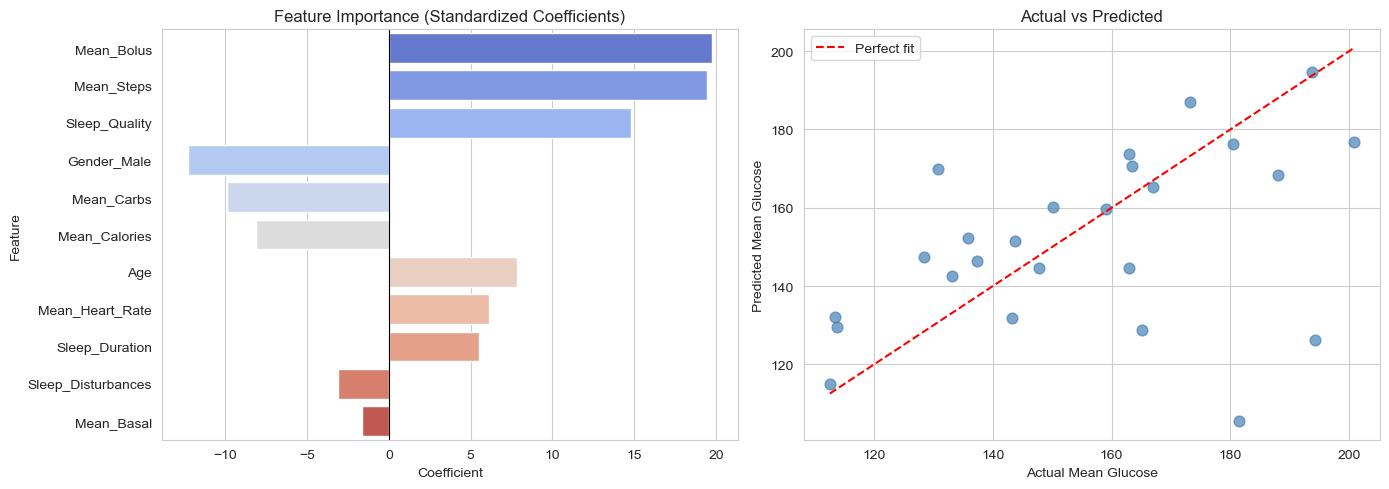

In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load and aggregate to patient level
df = pd.read_csv("/Users/tejaswinimode/Desktop/NUMPY/PyHackathon/Final cleaned csv files/Team2_PyQueens_Merged_Final.csv")

patient_df = (
    df.groupby("Patient_Id")
      .agg(Mean_Glucose=("Glucose", "mean"),
           Mean_Steps=("Steps", "mean"),
           Mean_Calories=("Calories", "mean"),
           Mean_Heart_Rate=("Heart_Rate", "mean"),
           Mean_Carbs=("Carb_Input", "mean"),
           Mean_Bolus=("Bolus_Volume_Delivered", "mean"),
           Mean_Basal=("Basal_Rate", "mean"),
           Age=("Age", "first"),
           Gender=("Gender", "first"),
           Sleep_Quality=("Sleep Quality (1-10)", "first"),
           Sleep_Duration=("Average Sleep Duration (hrs)", "first"),
           Sleep_Disturbances=("% with Sleep Disturbances", "first"))
      .reset_index()
)

#encode Gender (Male=1, Female=0)
patient_df["Gender_Male"] = (patient_df["Gender"] == "Male").astype(int)

# Define X and y 
features = ["Age", "Gender_Male", "Mean_Steps", "Mean_Calories",
            "Mean_Heart_Rate", "Mean_Carbs", "Mean_Bolus", "Mean_Basal",
            "Sleep_Quality", "Sleep_Duration", "Sleep_Disturbances"]
X = patient_df[features]
y = patient_df["Mean_Glucose"]

#Standardize so coefficients are comparable 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#train/test split (small sample, so 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

## Fit 
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate 
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("--- Model Performance ---")
print(f"Train R²   : {r2_score(y_train, y_pred_train):.3f}")
print(f"Test  R²   : {r2_score(y_test,  y_pred_test):.3f}")
print(f"Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f} mg/dL")
print(f"Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_pred_test)):.2f} mg/dL")

# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=coef_df, x="Coefficient", y="Feature",
            palette="coolwarm", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Feature Importance (Standardized Coefficients)")

# Actual vs Predicted
all_pred = model.predict(X_scaled)
axes[1].scatter(y, all_pred, alpha=0.7, s=60, color="steelblue")
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="Perfect fit")
axes[1].set_xlabel("Actual Mean Glucose")
axes[1].set_ylabel("Predicted Mean Glucose")
axes[1].set_title("Actual vs Predicted")
axes[1].legend()

plt.tight_layout()
plt.savefig("R1_regression_results.png", dpi=150, bbox_inches="tight")
plt.show()


#### ****Conclusion****

#### The model can describe glucose patterns reasonably well in training (R² = 0.66) but fails to generalize to new patients (Test R² = −2.98), 
#### which is the dominant story in this output. The model is severely overfitting due to having 11 features and only 25 patient.
#### A negative R² on test data means the model performs worse than simply predicting the mean for every patient. 
#### With 25 patients, an 80/20 split leaves only 5 patients in the test set, too few to evaluate, and any unusual patient will dominate 
#### the score.Multiple linear regression on this 25-patient dataset produces an overfit model (Train R² = 0.66, Test R² = −2.98) 
#### that cannot reliably predict mean glucose for new patients. 

#### Even though the model fails as a predictor, the relative magnitudes still tell a story: Bolus, Steps, Sleep Quality, 
#### and Gender are the four most influential variables on patient level glucose. They aren't useful for forecasting an unseen patient, 
#### but they identify which features carry the most signal in this cohort, which is itself a useful exploratory finding.